# `structural_similarity` algorithm benchmark

Compares the three `StructuralAlgorithm` options (`indel`, `pq_gram`, `difflib`) on speed
across increasing document sizes, scaled to real-world DOM sizes reported by
[HTTP Archive](https://discuss.httparchive.org/t/are-there-any-stats-about-dom-sizes-in-modern-pages/1619):
the median page has ~600 DOM elements, heavy pages run 5,000-20,000, and we add a
100,000-node stress case beyond what real pages typically reach.
`difflib` is skipped above 20,000 nodes - its quadratic worst case would take minutes
per call there, and the trend is already clear from the smaller sizes.

This notebook is for exploration only; it is not part of the `html_similarity` package and is not shipped with it (see `pyproject.toml`'s `[tool.setuptools.packages.find]`, which only includes `html_similarity*`).

In [46]:
import timeit

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from html_similarity import StructuralAlgorithm, structural_similarity

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'indel': '#2a9d8f', 'pq_gram': '#e76f51', 'difflib': '#264653'}

## Speed benchmark

Each scenario below builds **two synthetic documents**: a single `<table>` containing `rows`
`<tr><td>...</td><td>...</td></tr>` rows - a stand-in for something like a long search-results
table or comment thread, where one small structure repeats many times. `doc1` and `doc2` are
byte-for-byte identical except for their **last row**, which differs in `doc2`. That mirrors the
realistic case `structural_similarity` is built for: two pages from the same template that differ
by one piece of data.

The `rows` values aren't round numbers by accident: each row contributes 3 tags (`tr`, `td`, `td`)
and there are 3 wrapper tags (`html`, `body`, `table`), so `rows` is chosen so that `rows * 3 + 3`
lands close to the node count named in the scenario label (e.g. `rows=200` -> ~600 nodes).

In [47]:
# (label, rows): rows is the number of <tr> table rows to generate; each row is 3
# tags (tr, td, td), so the resulting document has roughly rows * 3 + 3 nodes (the
# +3 is the html/body/table wrapper) - that's the node count named in each label.
SCENARIOS = [
    ('typical (httparchive median, ~600 nodes)', 200),
    ('heavy (~3,000 nodes)', 1000),
    ('very heavy (~8,000 nodes)', 2666),
    ('stress (~20,000 nodes)', 6666),
    ('large-scale (~100,000 nodes)', 33333),
]

# difflib's quadratic worst case makes it take minutes above this size;
# we already have enough samples below this point to see the trend.
DIFFLIB_MAX_NODES = 20_000


def make_table_html(rows: int, diff_at_end: bool) -> str:
    # Build rows as a list and replace the last element, rather than slicing
    # a fixed number of characters off the joined string - the row index's
    # digit count varies (0..rows-1), so a fixed-length slice cuts mid-tag.
    row_html = [f'<tr><td>{i}</td><td>x</td></tr>' for i in range(rows)]
    if diff_at_end:
        row_html[-1] = '<tr><td>changed</td><td>y</td></tr>'
    return f'<html><body><table>{"".join(row_html)}</table></body></html>'


def time_it(html1: str, html2: str, algorithm: StructuralAlgorithm, number: int) -> float:
    return timeit.timeit(lambda: structural_similarity(html1, html2, algorithm=algorithm), number=number) / number

In [48]:
records = []
for label, rows in SCENARIOS:
    html1 = make_table_html(rows, diff_at_end=False)
    html2 = make_table_html(rows, diff_at_end=True)
    nodes = rows * 3 + 2  # table + rows * (tr + 2 * td)
    number = max(1, 2000 // max(nodes, 1))

    for algorithm in StructuralAlgorithm:
        if algorithm is StructuralAlgorithm.DIFFLIB and nodes > DIFFLIB_MAX_NODES:
            continue  # would take minutes; quadratic trend is already clear below
        ms = time_it(html1, html2, algorithm, number) * 1000
        records.append({'scenario': label, 'nodes': nodes, 'algorithm': algorithm.value, 'ms': ms})

timings = pd.DataFrame.from_records(records)
timings.pivot(index='nodes', columns='algorithm', values='ms').style.format('{:.2f} ms', na_rep='skipped').background_gradient(cmap='Reds', axis=None)

algorithm,difflib,indel,pq_gram
nodes,,,
602,13.31 ms,1.38 ms,3.21 ms
3002,337.42 ms,3.34 ms,13.32 ms
8000,2388.90 ms,9.15 ms,32.63 ms
20000,14692.58 ms,22.94 ms,81.27 ms
100001,skipped,118.08 ms,403.71 ms


### Log-log view, with O(n) / O(n²) reference slopes

Plotting both axes on a log scale turns polynomial growth into straight lines, so the slope
tells you the complexity class directly. `difflib` tracks the O(n²) reference line here, and
does in general - that matches its own documented worst case (CPython's difflib source:
"quadratic time for the worst case").

`pq_gram` tracks O(n) here and in general - it's a hash-based multiset comparison, so its
cost doesn't depend on how similar the two documents are.

`indel` tracks O(n) **in this benchmark specifically**, but that's not its general worst-case
complexity. `doc1`/`doc2` here differ only in the last row, so they share one long common
prefix, and rapidfuzz's bit-parallel implementation trims that shared prefix/suffix before
running its core DP - confirmed by timing it directly on documents with **no** common prefix
or suffix at the same size, where it becomes clearly quadratic (matching its documented
`O(N/64 * M)` bit-parallel complexity - quadratic, just with a ~64x smaller constant than
difflib). The near-template-identical case benchmarked here is also the realistic use case
this library targets (comparing pages from the same template), so it's a fair benchmark - just
not evidence that `indel` is linear in the worst case.

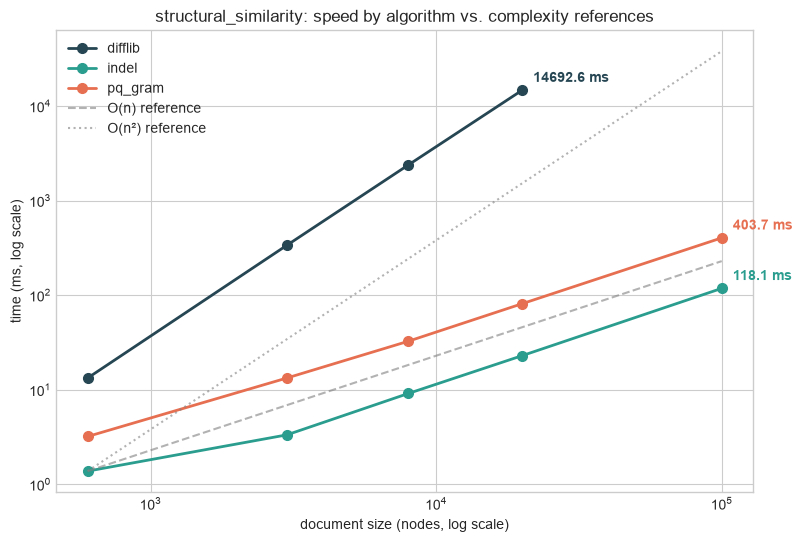

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

for algorithm, group in timings.groupby('algorithm'):
    group = group.sort_values('nodes')
    ax.plot(group['nodes'], group['ms'], marker='o', linewidth=2, markersize=7,
            color=COLORS[algorithm], label=algorithm)
    last = group.iloc[-1]
    ax.annotate(f"{last['ms']:.1f} ms", (last['nodes'], last['ms']),
                textcoords='offset points', xytext=(8, 6), color=COLORS[algorithm], fontweight='bold')

# reference slopes anchored to indel's first measurement
base_nodes = timings['nodes'].min()
base_ms = timings.loc[(timings['algorithm'] == 'indel') & (timings['nodes'] == base_nodes), 'ms'].iloc[0]
x_ref = np.array(sorted(timings['nodes'].unique()))
ax.plot(x_ref, base_ms * (x_ref / base_nodes), '--', color='gray', alpha=0.6, label='O(n) reference')
ax.plot(x_ref, base_ms * (x_ref / base_nodes) ** 2, ':', color='gray', alpha=0.6, label='O(n\u00b2) reference')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('document size (nodes, log scale)')
ax.set_ylabel('time (ms, log scale)')
ax.set_title('structural_similarity: speed by algorithm vs. complexity references')
ax.legend()
plt.show()

### Grouped bar view

Same data as a bar chart per scenario, with exact values labeled — easier to read off a
single number than the log-log plot above. Note: log scale on a bar chart is normally an
anti-pattern (bar length is supposed to encode magnitude from a zero baseline, which log
scale breaks), but it is the only way to keep `indel`/`pq_gram` visible next to `difflib`
here, since the values span 4+ orders of magnitude.

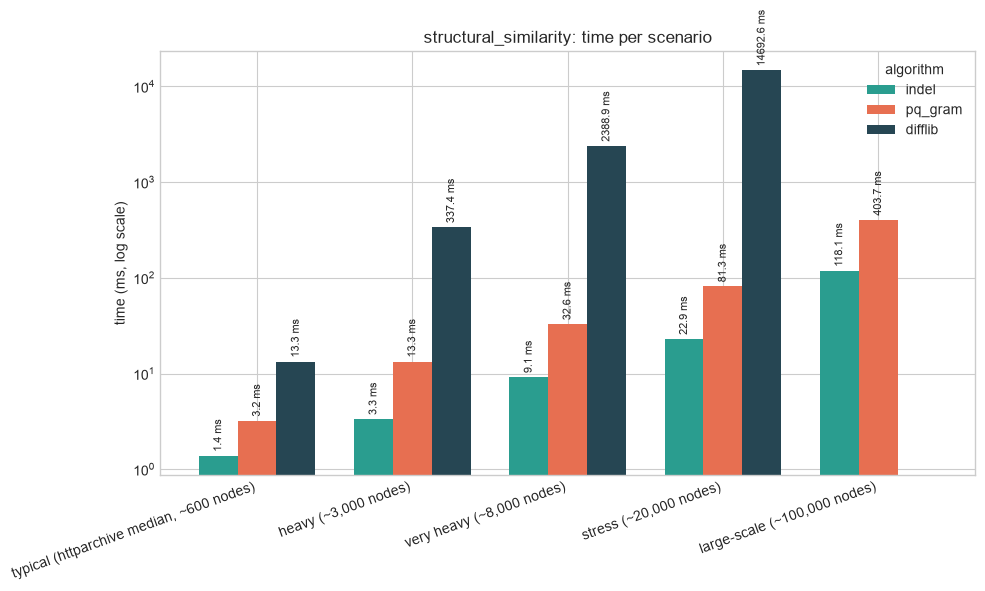

In [50]:
pivot = timings.pivot(index='scenario', columns='algorithm', values='ms').reindex([s for s, _ in SCENARIOS])
pivot = pivot[[a.value for a in StructuralAlgorithm]]

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot.bar(ax=ax, color=[COLORS[c] for c in pivot.columns], width=0.75)
ax.set_yscale('log')
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f'{v:.1f} ms' if v > 0 else '', rotation=90, padding=3, fontsize=8)

ax.set_ylabel('time (ms, log scale)')
ax.set_xlabel('')
ax.set_title('structural_similarity: time per scenario')
ax.legend(title='algorithm')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Speedup vs. `difflib`

How many times faster each alternative is, at every size where `difflib` actually completed.

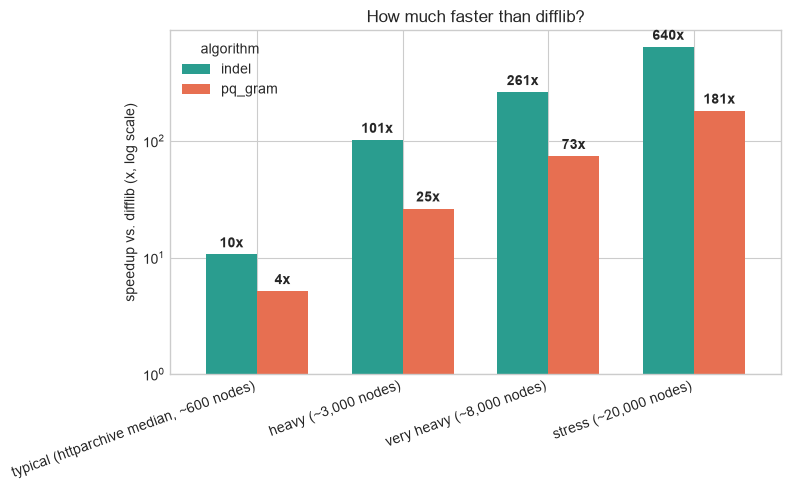

In [51]:
speedup = pivot.dropna(subset=['difflib']).copy()
speedup['indel'] = speedup['difflib'] / speedup['indel']
speedup['pq_gram'] = speedup['difflib'] / speedup['pq_gram']
speedup = speedup[['indel', 'pq_gram']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = speedup.plot.bar(ax=ax, color=[COLORS['indel'], COLORS['pq_gram']], width=0.7, log=True)
for container in bars.containers:
    ax.bar_label(container, fmt='%.0fx', padding=3, fontweight='bold')

ax.set_ylabel('speedup vs. difflib (x, log scale)')
ax.set_xlabel('')
ax.set_title('How much faster than difflib?')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Diff pattern benchmark

Every scenario above differs in exactly one row, at the end. Real document pairs can differ
in different ways: one change at the start, one in the middle, several changes scattered
throughout, or no shared rows at all. This section times all three algorithms against the same
document size (~3,000 nodes) under five different diff patterns.

In [52]:
PATTERN_ROWS = 1000  # ~3,000 nodes


def pattern_row_html(i: int, variant: str) -> str:
    if variant == 'same':
        return f'<tr><td>{i}</td><td>x</td></tr>'
    if variant == 'changed':
        # an extra <b> wrapper actually changes the tag sequence, unlike editing text content
        return f'<tr><td><b>{i}</b></td><td>x</td></tr>'
    if variant == 'different':
        return f'<li>{i}</li>'
    raise ValueError(variant)


def make_pattern_pair(rows: int, pattern: str) -> tuple[str, str]:
    base_rows = [pattern_row_html(i, 'same') for i in range(rows)]
    changed_rows = list(base_rows)

    if pattern == 'one change at the end':
        changed_rows[-1] = pattern_row_html(rows - 1, 'changed')
    elif pattern == 'one change at the start':
        changed_rows[0] = pattern_row_html(0, 'changed')
    elif pattern == 'one change in the middle':
        changed_rows[rows // 2] = pattern_row_html(rows // 2, 'changed')
    elif pattern == 'scattered changes (10% of rows)':
        for i in range(0, rows, 10):
            changed_rows[i] = pattern_row_html(i, 'changed')
    elif pattern == 'no shared rows':
        changed_rows = [pattern_row_html(i, 'different') for i in range(rows)]
    else:
        raise ValueError(pattern)

    doc1 = f'<html><body><table>{"".join(base_rows)}</table></body></html>'
    doc2 = f'<html><body><table>{"".join(changed_rows)}</table></body></html>'
    return doc1, doc2


PATTERNS = [
    'one change at the end',
    'one change at the start',
    'one change in the middle',
    'scattered changes (10% of rows)',
    'no shared rows',
]

In [53]:
pattern_records = []
for pattern in PATTERNS:
    html1, html2 = make_pattern_pair(PATTERN_ROWS, pattern)
    for algorithm in StructuralAlgorithm:
        ms = time_it(html1, html2, algorithm, number=3) * 1000
        pattern_records.append({'pattern': pattern, 'algorithm': algorithm.value, 'ms': ms})

pattern_timings = pd.DataFrame.from_records(pattern_records)
pattern_pivot = pattern_timings.pivot(index='pattern', columns='algorithm', values='ms').reindex(PATTERNS)
pattern_pivot = pattern_pivot[[a.value for a in StructuralAlgorithm]]
pattern_pivot.style.format('{:.2f} ms')

algorithm,indel,pq_gram,difflib
pattern,,,
one change at the end,3.93 ms,22.08 ms,329.59 ms
one change at the start,3.48 ms,12.30 ms,335.89 ms
one change in the middle,3.47 ms,12.42 ms,419.50 ms
scattered changes (10% of rows),3.64 ms,12.48 ms,11215.28 ms
no shared rows,2.35 ms,7.91 ms,2.76 ms


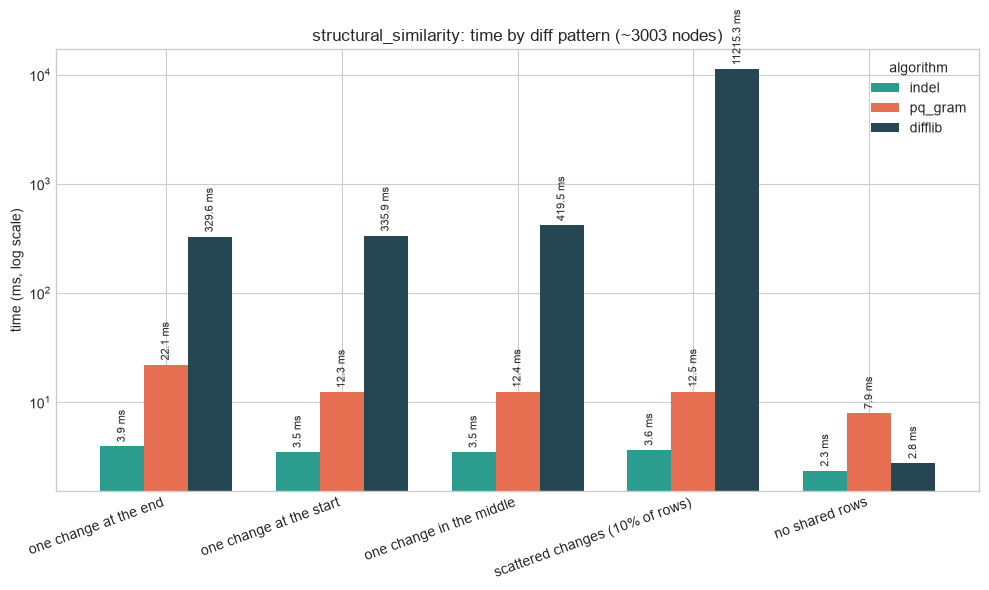

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))
pattern_pivot.plot.bar(ax=ax, color=[COLORS[c] for c in pattern_pivot.columns], width=0.75)
ax.set_yscale('log')
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f'{v:.1f} ms' if v > 0 else '', rotation=90, padding=3, fontsize=8)

ax.set_ylabel('time (ms, log scale)')
ax.set_xlabel('')
ax.set_title(f'structural_similarity: time by diff pattern (~{PATTERN_ROWS * 3 + 3} nodes)')
ax.legend(title='algorithm')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()